In [12]:
from notebooks.utils import get_data, clean_data
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
from src.utils import save_object
import os

In [3]:
raw_data_path = r'c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\raw'

elina_df = get_data(raw_data_path+"\elina_export.xml")
elina_df["user"]="elina"

oli_df = get_data(raw_data_path+"\oli_export.xml")
oli_df["user"]="oli"

dfs_to_concat = [elina_df, oli_df]
df = pd.concat(dfs_to_concat)

In [4]:
df.head(1)

,type,source_name,source_version,device,unit,creation_date,start_date,end_date,value,user
0,HKQuantityTypeIdentifierHeight,Health,13.3,Health,cm,2020-04-16 19:44:35 +0200,2020-04-16 19:44:35 +0200,2020-04-16 19:44:35 +0200,170,elina


In [5]:
df.tail(1)

,type,source_name,source_version,device,unit,creation_date,start_date,end_date,value,user
160215,HKQuantityTypeIdentifierHeadphoneAudioExposure,iPhone (2),15.6.1,iPhone (2),dBASPL,2022-10-24 06:51:20 +0200,2022-10-24 06:26:00 +0200,2022-10-24 06:26:02 +0200,27.5575,oli


# Cleaning

Output: a df that contains a date, user and values columns

In [6]:
clean_df = clean_data(df)
oli = clean_df[clean_df['user']=='oli']
elina = clean_df[clean_df['user']=='elina']

In [7]:
print(f"Cleaned df: \n{clean_df.tail()}")
print(f"oli df: \n{oli.head()}")
print(f"elina df: \n{elina.head()}")


Cleaned df: 
           date   user  value
3712 2024-09-24  elina   5271
3713 2024-09-25  elina    779
3714 2024-09-26  elina    238
3715 2024-09-27  elina   1444
3716 2024-09-28  elina    178
oli df: 
        date user  value
0 2018-11-18  oli   4390
1 2018-11-19  oli   8335
2 2018-11-20  oli   6946
3 2018-11-21  oli   8350
4 2018-11-22  oli  11054
elina df: 
          date   user  value
412 2020-01-04  elina    184
498 2020-03-29  elina    185
500 2020-03-30  elina   5432
502 2020-03-31  elina   2189
504 2020-04-01  elina   2933


In [8]:
user_list = [oli, elina] 
for user in user_list:
    user.drop(columns='user', errors='ignore', inplace=True)

C:\Users\olish\AppData\Local\Temp\ipykernel_16920\791318774.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user.drop(columns='user', errors='ignore', inplace=True)
C:\Users\olish\AppData\Local\Temp\ipykernel_16920\791318774.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user.drop(columns='user', errors='ignore', inplace=True)


In [9]:
print(f"oli's df: \n{oli.head()}")
print("")
print(f"elina's df: \n{elina.head()}")

oli's df: 
        date  value
0 2018-11-18   4390
1 2018-11-19   8335
2 2018-11-20   6946
3 2018-11-21   8350
4 2018-11-22  11054

elina's df: 
          date  value
412 2020-01-04    184
498 2020-03-29    185
500 2020-03-30   5432
502 2020-03-31   2189
504 2020-04-01   2933


In [10]:
print(f"clean df shape: \n{clean_df.shape[0]}")
print(f"oli's shape: \n{oli.shape[0]}")
print(f"elina's shape: \n{elina.shape[0]}")
print(f"oli and elina's combined shape: \n{oli.shape[0] + elina.shape[0]}")

clean df shape: 
3717
oli's shape: 
2072
elina's shape: 
1645
oli and elina's combined shape: 
3717


In [15]:
save_dir = r'c:\Users\olish\Documents\ml_projects\Steps_Predictor\model\data\clean\steps'

dfs = {
    'oli':oli,
    'elina':elina,
    'combined':clean_df
}

for name, df in dfs.items():
    file_path = os.path.join(save_dir, f"{name}.pkl")
    save_object(file_path, df)

### Conclusions:
- The cummulated count for each day does not match the count shown on the app interface
- Data types: datetime and int
- value is continuous data
- date is ordinal
- There is four and a half years worth of data

# Inspection

In [59]:
print(f"Shape of Oli's df: \n{oli.shape}")
print(f"Shape of Elina's df: \n{elina.shape}")

Shape of Oli's df: 
(2072, 2)
Shape of Elina's df: 
(1645, 2)


In [55]:
elina_description = elina['value'].describe()
oli_description = oli['value'].describe()

elina_desc = pd.DataFrame(elina_description).rename(columns={'value': "elina"})
oli_desc = pd.DataFrame(oli_description).rename(columns={'value': "oli"})

combined_description = pd.concat([elina_desc, oli_desc], axis=1)
print(combined_description)

              elina           oli
count   1645.000000   2072.000000
mean    4520.144681   8108.018822
std     3050.355697   3387.438724
min        6.000000    292.000000
25%     2298.000000   5834.750000
50%     4049.000000   7832.000000
75%     6319.000000   9916.250000
max    22171.000000  23919.000000


In [61]:
elina.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1645 entries, 0 to 1644
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1645 non-null   datetime64[ns]
 1   value   1645 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 25.8 KB


In [62]:
oli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2072 entries, 0 to 2071
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2072 non-null   datetime64[ns]
 1   value   2072 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 32.5 KB


# Quality

In [30]:
oli_date_duplicates = oli[oli.duplicated('date', keep=False)]
print(f"oli's date duplicates: \n{oli_date_duplicates.shape[0]}")

elina_date_duplicates = elina[elina.duplicated('date', keep=False)]
print(f"elina's date duplicates: \n{elina_date_duplicates.shape[0]}")

oli's date duplicates: 
0
elina's date duplicates: 
0


C:\Users\olish\AppData\Local\Temp\ipykernel_26356\4073495502.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


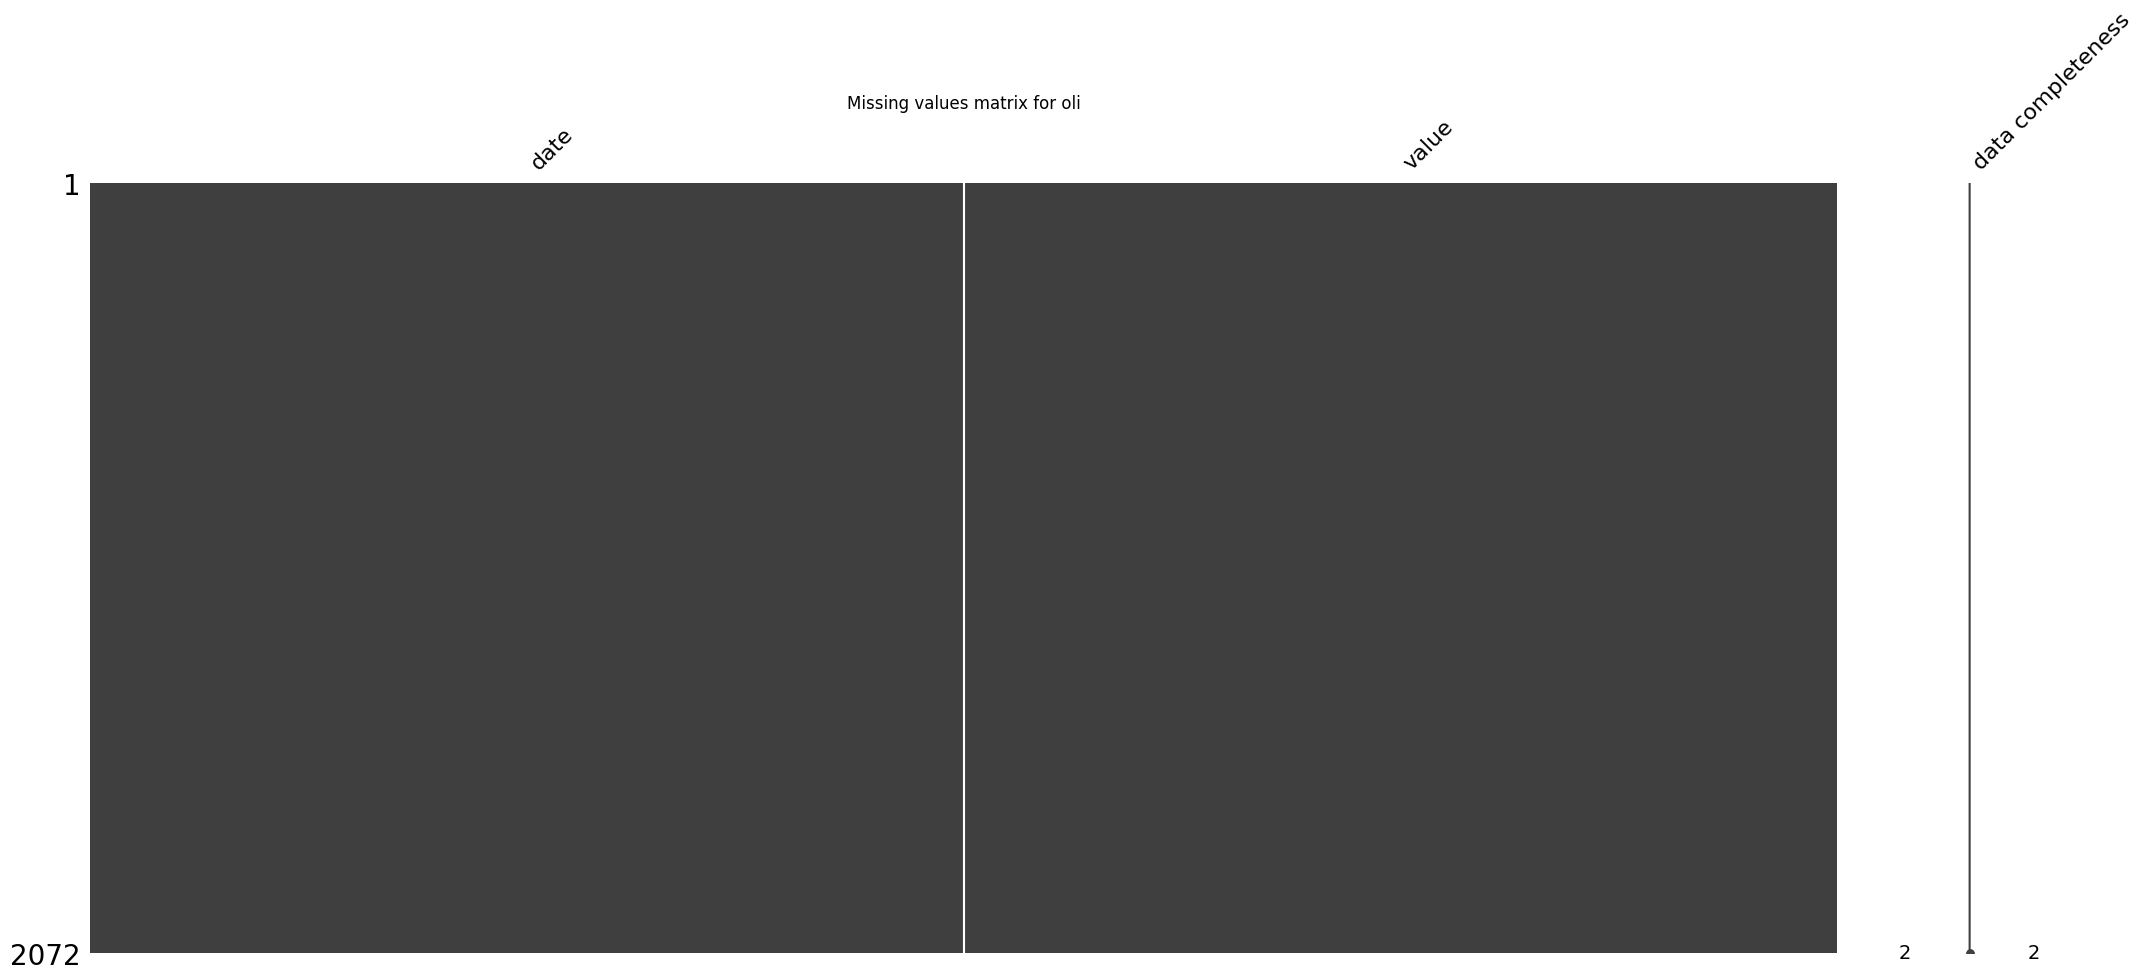

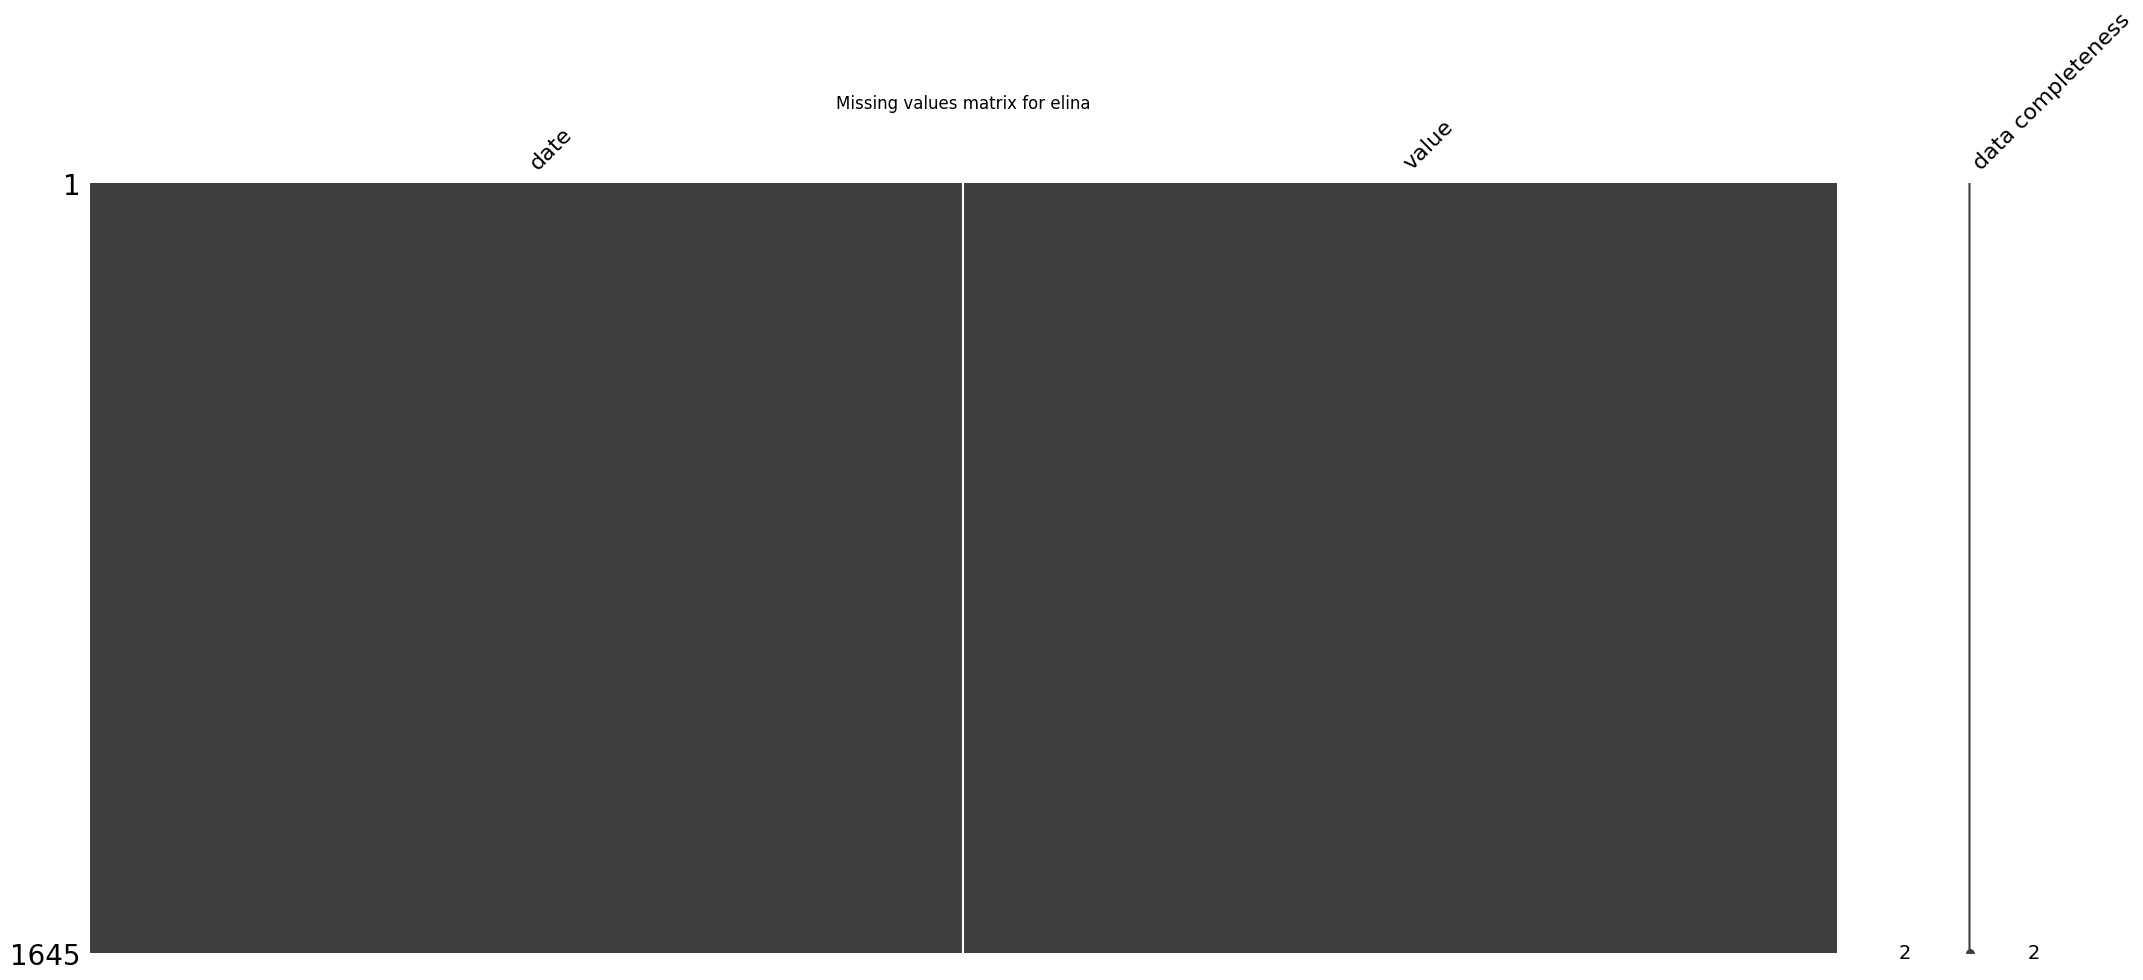

In [54]:
users = {
    'oli': oli,
    'elina': elina
}

for user in users:
    msno.matrix(users[user], labels=True, sort="descending")
    plt.title(f"Missing values matrix for {user}")
plt.tight_layout()